In [1]:
from timescale import TimescaleDBManager
from dotenv import load_dotenv
from sqlalchemy import create_engine
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import joblib
import json
import re
from functools import partial

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import IsolationForest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,accuracy_score, precision_score, recall_score, f1_score,classification_report
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score, roc_curve, RocCurveDisplay
from sklearn.inspection import permutation_importance

from sklearn.preprocessing import LabelEncoder


from tensorflow.keras import layers, models
from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense,BatchNormalization, Dropout, LSTM,RepeatVector, TimeDistributed

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.callbacks import EarlyStopping

from scikeras.wrappers import KerasRegressor
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import optuna
import tensorflow as tf
import seaborn as sns
import time







In [2]:
load_dotenv()
user_env        = os.getenv("USER_DB")
pass_env        = os.getenv("PASS_DB")
host_env        = os.getenv("HOST_DB", "localhost")
port_env        = os.getenv("DB_PORT_EXPOSED", "5432")
db_env          = os.getenv("NAME_DB", "tfm_db")
FOLDER_SALIDA   = os.getenv("FOLDER_SALIDA")
FOLDER_TMP      = os.getenv("FOLDER_TMP")

SEED            = 100#int(os.getenv("SEED"))

db = TimescaleDBManager(
    user=user_env,
    password=pass_env,
    host=host_env,
    port=port_env,
    dbname=db_env
)
db.conectar()
conexion_postgresql = db.connection

#esto es para usar una conexion postgrews para pandas que da un warning indicando que solo esta testeado para sqlalchemy
engine = create_engine(f'postgresql+psycopg2://{user_env}:{pass_env}@{host_env}:{port_env}/{db_env}')

[OK] Conexión establecida con TimescaleDB.


In [3]:
SQL='select * from vectores'
df = pd.read_sql(SQL, engine)


In [4]:
lista_label = df['label'].unique().tolist()

In [5]:
df_result=df[ ['vector_id','execution_name','label'] ].copy()

In [6]:
df_result

,vector_id,execution_name,label
0,190754,light-oauth2-data-1719592986.tar,correct
1,190755,light-oauth2-data-1719592986.tar,correct
2,190756,light-oauth2-data-1719592986.tar,correct
3,190757,light-oauth2-data-1719592986.tar,correct
4,190843,light-oauth2-data-1719594842.tar,invalid_code_verifier_format_PKCE_400
...,...,...,...
90185,280939,light-oauth2-data-1725866154.tar,delete_user_404_no_user
90186,280940,light-oauth2-data-1725866154.tar,update_password_401_wrong_password
90187,280941,light-oauth2-data-1725866154.tar,update_password_404_user_not_found
90188,280942,light-oauth2-data-1725866154.tar,update_password_400_not_match


In [7]:
filename = f'{FOLDER_SALIDA}/lista_metric_name_vector.json'

with open(filename, "r", encoding="utf-8") as f:
    lista_metric_name_vector = json.load(f)

lista_limpia = [metrica.split('(')[0] for metrica in lista_metric_name_vector]

# 2. Contar los valores únicos totales
valores_unicos = set(lista_limpia)
N_metric_value = len(valores_unicos)

# <span style="color:#2ca02c">1. Recuperamos separación ya hecha en conjuntos de train, val y test</span>

In [8]:
SQL='select * from vectores_split'
df_split = pd.read_sql(SQL, engine)

In [9]:
df_result = pd.merge(df_result, df_split, on="vector_id", how="inner")

In [10]:
df_result

,vector_id,execution_name,label,split_type
0,190754,light-oauth2-data-1719592986.tar,correct,test
1,190755,light-oauth2-data-1719592986.tar,correct,train
2,190756,light-oauth2-data-1719592986.tar,correct,train
3,190757,light-oauth2-data-1719592986.tar,correct,test
4,190843,light-oauth2-data-1719594842.tar,invalid_code_verifier_format_PKCE_400,train
...,...,...,...,...
90185,280939,light-oauth2-data-1725866154.tar,delete_user_404_no_user,train
90186,280940,light-oauth2-data-1725866154.tar,update_password_401_wrong_password,val
90187,280941,light-oauth2-data-1725866154.tar,update_password_404_user_not_found,train
90188,280942,light-oauth2-data-1725866154.tar,update_password_400_not_match,val


In [11]:
dic_idx_train = {}
#dic_idx_resto = {}
dic_idx_val   = {}
dic_idx_test  = {}

In [12]:
for label in lista_label:
    idx_train = df_result[  (df_result['label']==label) & (df_result['split_type'] == 'train') ].index.values
    idx_val   = df_result[  (df_result['label']==label) & (df_result['split_type'] == 'val'  ) ].index.values
    idx_test  = df_result[  (df_result['label']==label) & (df_result['split_type'] == 'test') ].index.values
    dic_idx_train[label] = idx_train
    dic_idx_val[label]   = idx_val
    dic_idx_test[label]  = idx_test

<span style="color:#2ca02c"> Convetimos los vectores del df en una matriz, seran los datos que pasemos a los algoritmo   </span>


In [13]:
X_matrix = np.array(df['vector'].tolist())
X_matrix.shape

(90190, 354)

In [14]:
timesteps = 3

X_matrix_LSTM = X_matrix.reshape((X_matrix.shape[0], timesteps, N_metric_value))

In [15]:
X_matrix_LSTM.shape

(90190, 3, 118)

# <span style="color:#2ca02c">2. Preparacion de datos para entrenamiento/test</span>

In [16]:
lista_result=[]

In [17]:
idx_correct_train = dic_idx_train['correct']
idx_correct_val   = dic_idx_val['correct']
idx_correct_test  = dic_idx_test['correct']

In [18]:
N_datos_test_por_anomalia = int( len(idx_correct_test)  / (len(lista_label)-1) )

In [19]:
idx_test =idx_correct_test.copy()
for label in lista_label:
    if label=='correct':
        continue
    if len(dic_idx_test[label])<N_datos_test_por_anomalia:
        idx_test = np.concatenate((idx_test, dic_idx_test[label]))
    else:
        #idx_test.extend(dic_idx_test[label][:N_datos_test_por_anomalia])
        # Corrección: pon los dos arrays dentro de un paréntesis
        idx_test = np.concatenate((idx_test, dic_idx_test[label][:N_datos_test_por_anomalia]))
        
X_test  = X_matrix_LSTM[idx_test]

In [20]:
X_correct_train = X_matrix_LSTM[idx_correct_train]
X_correct_test  = X_matrix_LSTM[idx_correct_test]

In [21]:
df_result = pd.DataFrame({
    't_rel': df.loc[idx_test, 't_rel'],
    'execution_name': df.loc[idx_correct_test, 'execution_name'],
    'label': df.loc[idx_test, 'label']
})

# <span style="color:#2ca02c">3. Detección de anomalías</span>

## <span style="color:#2ca02c">3.1. Optimizacion con optuna</span>

In [22]:


input_shape = (timesteps, N_metric_value)

# 3. Callback de verbose para ver el progreso de Optuna
def print_callback(study, trial):

    p = trial.params
    # Leemos el atributo que guardamos en el trial
    actual_epochs = trial.user_attrs.get('actual_epochs', 'N/D')
    max_epochs = p.get('epochs')
    
    print(f"Trial {trial.number} finalizado | Mejor Loss (MSE): {study.best_value:.6f} | Parámetros: {trial.params} |"
         f"Épocas: {actual_epochs}/{max_epochs} (reales/máx) ")


def create_lstm_autoencoder(units, dropout_rate, learning_rate, input_shape):
    model = Sequential([
        # Dropout integrado en la LSTM del Encoder
        LSTM(units, input_shape=input_shape, return_sequences=False, dropout=dropout_rate),
        RepeatVector(input_shape[0]),
        # Dropout integrado en la LSTM del Decoder
        LSTM(units, return_sequences=True, dropout=dropout_rate),
        TimeDistributed(Dense(input_shape[1]))
    ])
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse')
    return model



# 5. Función objetivo de Optuna recibiendo el diccionario externo
def objective_lstm_ae(trial, config):
    units = trial.suggest_categorical('units', config['units'])
    learning_rate = trial.suggest_categorical('learning_rate', config['learning_rate'])
    batch_size = trial.suggest_categorical('batch_size', config['batch_size'])
    epochs = trial.suggest_categorical('epochs', config['epochs'])
    dropout_rate = trial.suggest_categorical('dropout_rate', config['dropout_rate'])
    
    model = create_lstm_autoencoder(
        units=units,
        dropout_rate=dropout_rate,
        learning_rate=learning_rate,
        input_shape=input_shape
    )
    
    early_stopping = EarlyStopping(
        monitor='loss',
        patience=3,
        restore_best_weights=True,
        verbose=0
    )
    
    # Entrenamiento exclusivo con datos correctos extraídos de X_matrix_lstm
    history = model.fit(
        X_correct_train, X_correct_train,
        batch_size=batch_size,
        epochs=epochs,
        callbacks=[early_stopping],
        verbose=0
    )
    
    #recuperamos el numero de epocas realizadas para mostrarlas en el resultado
    actual_epochs = len(history.history['loss'])
    trial.set_user_attr('actual_epochs', actual_epochs)
    
    return min(history.history['loss'])






In [31]:
T_ini=time.time()
# 6. Definición externa de hiperparámetros
params_grid_lstm_ae = {
    'units': [32, 64, 128],
    'dropout_rate': [0.0, 0.1, 0.2, 0.3], # Tasas de dropout a evaluar
    'learning_rate': [0.01, 0.001, 0.0005],
    'batch_size': [32, 64],
    'epochs': [50]
}

# 7. Crear el estudio Optuna (minimize porque buscamos el menor error de reconstrucción MSE)
study_lstm_ae = optuna.create_study(direction='minimize')

# 8. Enlazar la función con los parámetros mediante partial
objective_func_lstm_ae = partial(objective_lstm_ae, config=params_grid_lstm_ae)

# 9. Ejecutar la optimización
print("=== INICIANDO OPTIMIZACIÓN DE LSTM AUTOENCODER ===")
study_lstm_ae.optimize(objective_func_lstm_ae, n_trials=100, callbacks=[print_callback], n_jobs=-1)
T_fin=time.time()

[I 2026-09-11 11:21:18,043] A new study created in memory with name: no-name-4542142e-53f0-48a0-9562-e98de3f66234


=== INICIANDO OPTIMIZACIÓN DE LSTM AUTOENCODER ===


[I 2026-09-11 11:27:15,064] Trial 2 finished with value: 0.10082297772169113 and parameters: {'units': 32, 'learning_rate': 0.01, 'batch_size': 64, 'epochs': 50, 'dropout_rate': 0.0}. Best is trial 2 with value: 0.10082297772169113.


Trial 2 finalizado | Mejor Loss (MSE): 0.100823 | Parámetros: {'units': 32, 'learning_rate': 0.01, 'batch_size': 64, 'epochs': 50, 'dropout_rate': 0.0} |Épocas: 50/50 (reales/máx) 


[I 2026-09-11 11:27:26,965] Trial 18 finished with value: 0.1556960791349411 and parameters: {'units': 32, 'learning_rate': 0.0005, 'batch_size': 64, 'epochs': 50, 'dropout_rate': 0.1}. Best is trial 2 with value: 0.10082297772169113.


...

Trial 82 finalizado | Mejor Loss (MSE): 0.009348 | Parámetros: {'units': 128, 'learning_rate': 0.001, 'batch_size': 32, 'epochs': 50, 'dropout_rate': 0.0} |Épocas: 50/50 (reales/máx) 


[I 2026-09-11 12:35:09,695] Trial 84 finished with value: 0.00991027895361185 and parameters: {'units': 128, 'learning_rate': 0.001, 'batch_size': 32, 'epochs': 50, 'dropout_rate': 0.0}. Best is trial 42 with value: 0.009347764775156975.


Trial 84 finalizado | Mejor Loss (MSE): 0.009348 | Parámetros: {'units': 128, 'learning_rate': 0.001, 'batch_size': 32, 'epochs': 50, 'dropout_rate': 0.0} |Épocas: 50/50 (reales/máx) 


[I 2026-09-11 12:35:15,654] Trial 83 finished with value: 0.009962707757949829 and parameters: {'units': 128, 'learning_rate': 0.001, 'batch_size': 32, 'epochs': 50, 'dropout_rate': 0.0}. Best is trial 42 with value: 0.009347764775156975.


Trial 83 finalizado | Mejor Loss (MSE): 0.009348 | Parámetros: {'units': 128, 'learning_rate': 0.001, 'batch_size': 32, 'epochs': 50, 'dropout_rate': 0.0} |Épocas: 50/50 (reales/máx) 


In [32]:
study_lstm_ae.best_params

{'units': 128,
 'learning_rate': 0.001,
 'batch_size': 32,
 'epochs': 50,
 'dropout_rate': 0.0}

In [33]:
print('Tiempo de optimizacion de hiperparámetros: %.1f'%(T_fin-T_ini))

Tiempo de optimizacion de hiperparámetros: 4437.6


## <span style="color:#2ca02c">3.2. Entrenamiento profundo del LSTM AE con los hiperparámetros optimizados</span>

In [34]:
lista_result=[]
mejores_params = study_lstm_ae.best_params
# mejores_params = {'units': 128,
#  'learning_rate': 0.001,
#  'batch_size': 32,
#  'epochs': 50,
#  'dropout_rate': 0.0}

In [36]:
T_ini=time.time()
print("\n=== MEJOR COMBINACIÓN ENCONTRADA (LSTM AUTOENCODER) ===")
print(mejores_params)
print(f"Mejor Loss (MSE): {study_lstm_ae.best_value:.6f}")


#mejores_params = study_lstm_ae.best_params

lstm_ae_opt = create_lstm_autoencoder(
    units=mejores_params['units'],
    learning_rate=mejores_params['learning_rate'],
    input_shape=input_shape,
    dropout_rate=mejores_params['dropout_rate']
)


early_stopping_final = EarlyStopping(
    monitor='loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

mejores_params['epochs']=500


print("\nIniciando entrenamiento del modelo definitivo...")
history_final = lstm_ae_opt.fit(
    X_correct_train, X_correct_train,
    batch_size=mejores_params['batch_size'],
    epochs=mejores_params['epochs'],
    callbacks=[early_stopping_final],
    verbose=1
)
T_fin=time.time()


=== MEJOR COMBINACIÓN ENCONTRADA (LSTM AUTOENCODER) ===
{'units': 128, 'learning_rate': 0.001, 'batch_size': 32, 'epochs': 300, 'dropout_rate': 0.0}
Mejor Loss (MSE): 0.009348

Iniciando entrenamiento del modelo definitivo...
Epoch 1/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - loss: 0.1830
Epoch 2/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - loss: 0.1165
Epoch 3/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - loss: 0.0939
Epoch 4/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - loss: 0.0779
Epoch 5/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - loss: 0.0649
Epoch 6/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - loss: 0.0523
Epoch 7/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 0.0426
Epoch 8/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - loss: 0.0369
Epoch 9/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - loss: 0.0326
Epoch 10/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - loss: 0.0292
Epoch 11/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - loss: 0.0267
Epoch 12/50

In [37]:
print('Tiempo de entrenamiento: %.1f'%(T_fin-T_ini))

Tiempo de entrenamiento: 1779.6


In [27]:
# 1. Calculas los errores en el train limpio
reconstructions_train = lstm_ae_opt.predict(X_correct_train)
train_scores = np.mean(np.power(X_correct_train - reconstructions_train, 2), axis=1)

# 2. Defines el umbral basándote en el train (ej. el percentil 95 o 99 de los normales)
threshold_percentil_scores = 99.9
threshold = np.percentile(train_scores, threshold_percentil_scores)

320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step



Calculando errores de reconstrucción en el conjunto de test...


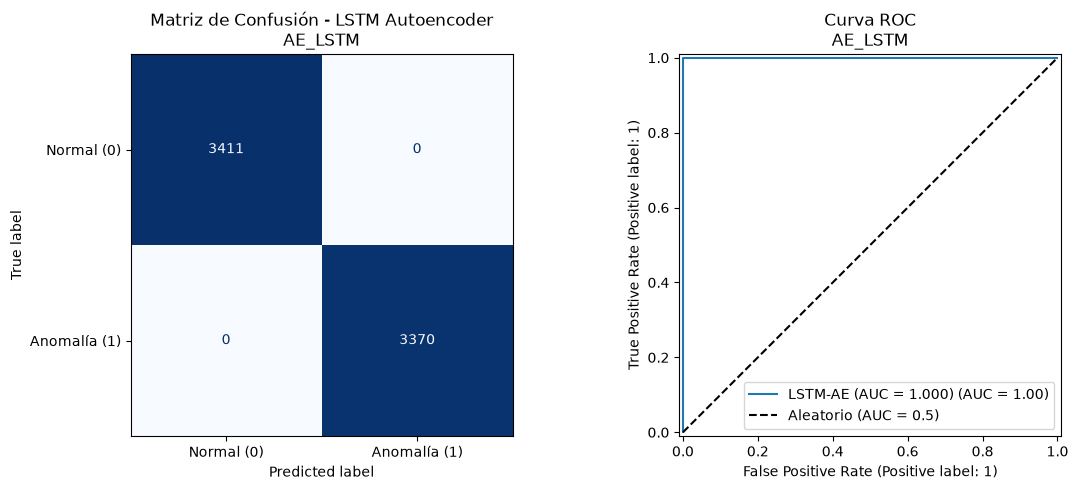

In [28]:


# 1. Calcular los scores (Error de reconstrucción MSE promediando timesteps y features por muestra)
print("\nCalculando errores de reconstrucción en el conjunto de test...")
reconstructions = lstm_ae_opt.predict(X_test, verbose=0)
scores = np.mean(np.power(X_test - reconstructions, 2), axis=(1, 2))

reconstructions_train = lstm_ae_opt.predict(X_correct_train, verbose=0)
train_scores = np.mean(np.power(X_correct_train - reconstructions_train, 2), axis=(1, 2))


# Predicción: Si el MSE supera el umbral es anomalía (1), si no, normal (0)
y_pred = np.where(scores > threshold, 1, 0)

model_name = 'AE_LSTM'

# 3. Obtener las etiquetas reales (y_true) correctamente desde el DataFrame de test
y_true = df_result.loc[idx_test, 'label'].apply(lambda x: 0 if x == 'correct' else 1).values

# Cálculo del AUC-ROC (a mayor error de reconstrucción / score, mayor probabilidad de anomalía)
roc_auc = roc_auc_score(y_true, scores)

# 4. Componentes de la matriz de confusión
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

# 5. Cálculo de métricas
acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = f1_score(y_true, y_pred, zero_division=0)

parametros = mejores_params.copy() if 'mejores_params' in locals() else {}
parametros['threshold_percentil_scores'] = threshold_percentil_scores

# 6. Guardar en el registro (añadiendo roc_auc)
reg_resultado_algoritmo = {
    'test_name': model_name,
    'parametros': json.dumps(parametros),
    'TP': int(tp),
    'FP': int(fp),
    'TN': int(tn),
    'FN': int(fn),
    'accuracy': float(acc),
    'precision': float(precision),
    'recall': float(recall),
    'specificity': float(specificity),
    'f1_score': float(f1),
    'roc_auc': float(roc_auc)
}

if 'lista_result' not in locals():
    lista_result = []

lista_result.append(reg_resultado_algoritmo)
df_anomaly_detection_summary = pd.DataFrame(lista_result)

# 7. Visualización conjunta (Matriz de Confusión a la izquierda, Curva ROC a la derecha)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfica izquierda: Matriz de Confusión
disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Anomalía (1)'])
disp_cm.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Matriz de Confusión - LSTM Autoencoder\n{model_name}')

# Gráfica derecha: Curva ROC
RocCurveDisplay.from_predictions(
    y_true, 
    scores, 
    ax=axes[1], 
    name=f'LSTM-AE (AUC = {roc_auc:.3f})'
)
axes[1].plot([0, 1], [0, 1], 'k--', label='Aleatorio (AUC = 0.5)')
axes[1].set_title(f'Curva ROC\n{model_name}')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

In [29]:
paquete_autoencoder = {
    'model': lstm_ae_opt,                # El modelo de Keras ya entrenado
    'metrics_list': lista_metric_name_vector,  # La lista con los nombres de las características
    'model_name': model_name, # Un identificador o nombre descriptivo
    'parametros': mejores_params           # Opcional: guardar los hiperparámetros ganadores
}
joblib.dump(paquete_autoencoder, f'{FOLDER_SALIDA}/models/{model_name}.joblib')

['result/models/AE_LSTM.joblib']

In [22]:
# paquete_joblib= joblib.load('result/models/AE_LSTM.joblib')

# # 2. Recuperar las variables y el modelo de Keras usando su ruta
# lstm_ae_opt = paquete_joblib['model']

In [30]:
df_anomaly_detection_summary

,test_name,parametros,TP,FP,TN,FN,accuracy,precision,recall,specificity,f1_score,roc_auc
0,AE_LSTM,"{""units"": 128, ""learning_rate"": 0.001, ""batch_...",3370,0,3411,0,1.0,1.0,1.0,1.0,1.0,1.0
